# 03.1 - Descriptive Statistics

**Phase:** 03 - Statistics & Probability

**Status:** VERIFIED

---

## 1. What Are We Solving?

Before any modeling, we need to **understand our data**. Descriptive statistics summarize a dataset with a few key numbers: where the data is centered (mean, median, mode), how spread out it is (variance, standard deviation, range), and its shape (quartiles, skewness).

## 2. Why Does This Matter?

Every ML project starts with **exploratory data analysis (EDA)**. Descriptive statistics reveal outliers, skewness, and scale issues that must be handled before training a model. They also tell you which model assumptions might be violated.

## 3. Prerequisites

- Phase 02 (Mathematics for ML)
- Unit 01.6 (Pandas)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Compute measures of central tendency (mean, median, mode)
- Compute measures of spread (variance, std, range, IQR)
- Understand quartiles and percentiles
- Detect skewness and outliers
- Use NumPy and Pandas to summarize data

## 5. Mental Model

Descriptive statistics answer two questions: **where is the data?** (central tendency) and **how spread out is it?** (dispersion). The **mean** is the balance point, the **median** is the middle value, and the **mode** is the most common value. When the mean and median differ, the data is **skewed**.


## 6. Central Tendency: Mean, Median, Mode

- **Mean**: the arithmetic average - sensitive to outliers.
- **Median**: the middle value when sorted - robust to outliers.
- **Mode**: the most frequent value - useful for categorical data.

Let's compute these on a small dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Small dataset
data = np.array([3, 5, 7, 7, 8, 9, 10, 12, 15, 100])

mean = np.mean(data)
median = np.median(data)
mode = stats.mode(data).mode

print(f"Data: {data}")
print(f"Mean:   {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Mode:   {mode}")
print("\nNote: the mean (17.6) is much larger than the median (8.5)")
print("because of the outlier 100. The median is robust to outliers.")


Data: [  3   5   7   7   8   9  10  12  15 100]
Mean:   17.60
Median: 8.50
Mode:   7

Note: the mean (17.6) is much larger than the median (8.5)
because of the outlier 100. The median is robust to outliers.


## 7. Measures of Spread

- **Range**: max - min.
- **Variance**: average squared deviation from the mean.
- **Standard deviation**: square root of variance - in the same units as the data.
- **IQR** (interquartile range): 75th percentile - 25th percentile.

Variance formula (population): `Var = (1/n) * sum((x - mean)^2)`

Sample variance uses `1/(n-1)` (Bessel's correction) to be unbiased.


In [2]:
# Measures of spread
data2 = np.array([4, 5, 6, 7, 8, 9, 10])  # low spread
data3 = np.array([1, 3, 6, 7, 9, 12, 15])  # higher spread

for name, d in [("data2 (low spread)", data2), ("data3 (high spread)", data3)]:
    print(f"{name}:")
    print(f"  Range: {np.ptp(d)}")
    print(f"  Variance (population): {np.var(d):.2f}")
    print(f"  Variance (sample):     {np.var(d, ddof=1):.2f}")
    print(f"  Std (population):      {np.std(d):.2f}")
    print(f"  Std (sample):          {np.std(d, ddof=1):.2f}")
    print()

print("data3 has higher variance/std because its values are more spread out.")


data2 (low spread):
  Range: 6
  Variance (population): 4.00
  Variance (sample):     4.67
  Std (population):      2.00
  Std (sample):          2.16

data3 (high spread):
  Range: 14
  Variance (population): 20.53
  Variance (sample):     23.95
  Std (population):      4.53
  Std (sample):          4.89

data3 has higher variance/std because its values are more spread out.


## 8. Quartiles and Percentiles

**Quartiles** divide sorted data into four equal parts:

- **Q1** (25th percentile): 25% of data below this.
- **Q2** (50th percentile): the median.
- **Q3** (75th percentile): 75% of data below this.
- **IQR** = Q3 - Q1: the middle 50% of data.

The **five-number summary** is min, Q1, median, Q3, max - the basis of box plots.


In [3]:
# Quartiles and percentiles
data4 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

q1 = np.percentile(data4, 25)
q2 = np.percentile(data4, 50)
q3 = np.percentile(data4, 75)
iqr = q3 - q1

print(f"Data: {data4}")
print(f"Min:  {np.min(data4)}")
print(f"Q1 (25th): {q1}")
print(f"Median (50th): {q2}")
print(f"Q3 (75th): {q3}")
print(f"Max:  {np.max(data4)}")
print(f"IQR:  {iqr}")
print("\nThis is the five-number summary used in box plots.")


Data: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Min:  1
Q1 (25th): 3.75
Median (50th): 6.5
Q3 (75th): 9.25
Max:  12
IQR:  5.5

This is the five-number summary used in box plots.


## 9. Skewness

**Skewness** measures asymmetry:

- **Positive skew** (right tail): mean > median, long tail to the right.
- **Negative skew** (left tail): mean < median, long tail to the left.
- **Zero skew**: symmetric (like the normal distribution).

Skewed data often needs transformation (e.g. log) before modeling.


right-skewed: skewness = 1.865, mean=1.95, median=1.37
symmetric: skewness = -0.037, mean=0.10, median=0.08
left-skewed: skewness = -1.651, mean=-1.94, median=-1.34


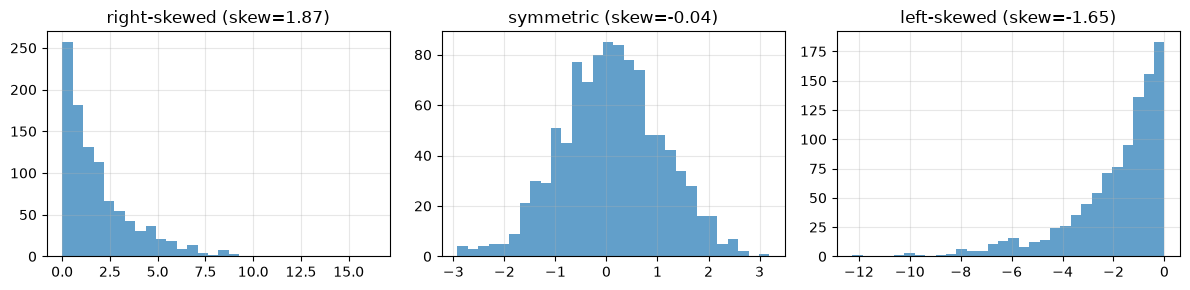

In [4]:
# Skewness
np.random.seed(42)

# Right-skewed data (e.g. income, house prices)
right_skew = np.random.exponential(scale=2, size=1000)
# Symmetric data
symmetric = np.random.normal(0, 1, 1000)
# Left-skewed data
left_skew = -np.random.exponential(scale=2, size=1000)

for name, d in [("right-skewed", right_skew), ("symmetric", symmetric), ("left-skewed", left_skew)]:
    sk = stats.skew(d)
    print(f"{name}: skewness = {sk:.3f}, mean={np.mean(d):.2f}, median={np.median(d):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, d, name in [(axes[0], right_skew, "right-skewed"),
                    (axes[1], symmetric, "symmetric"),
                    (axes[2], left_skew, "left-skewed")]:
    ax.hist(d, bins=30, alpha=0.7)
    ax.set_title(f"{name} (skew={stats.skew(d):.2f})")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Outliers

**Outliers** are extreme values that can distort statistics and models. A common rule: a value is an outlier if it's below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.


Data: [ 1  2  3  4  5  6  7  8  9 10 50]
Q1=3.5, Q3=8.5, IQR=5.0
Outlier bounds: [-4.00, 16.00]
Outliers detected: [50]


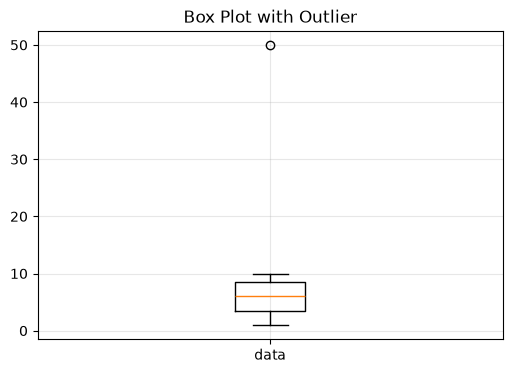

In [5]:
# Detecting outliers with the IQR rule
data5 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 50])  # 50 is an outlier

q1 = np.percentile(data5, 25)
q3 = np.percentile(data5, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = data5[(data5 < lower) | (data5 > upper)]
print(f"Data: {data5}")
print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Outlier bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Outliers detected: {outliers}")

# Box plot visualizes outliers
plt.figure(figsize=(6, 4))
plt.boxplot(data5, tick_labels=["data"])
plt.title("Box Plot with Outlier")
plt.grid(True, alpha=0.3)
plt.show()


## 11. Using Pandas for Descriptive Statistics

Pandas provides a convenient `describe()` method that computes all key statistics at once.


In [6]:
# Pandas describe()
np.random.seed(1)
df = pd.DataFrame({
    "age": np.random.randint(18, 70, 200),
    "income": np.random.exponential(50000, 200),
    "score": np.random.normal(75, 10, 200),
})

print(df.describe())
print("\nNote how income (right-skewed) has mean >> median, while")
print("score (normal) has mean ~ median.")


              age         income       score
count  200.000000     200.000000  200.000000
mean    40.935000   39747.992753   75.046987
std     14.768593   41300.282658    9.964443
min     18.000000     233.711026   50.425673
25%     28.000000    9172.775206   67.956123
50%     39.500000   25417.597886   75.538339
75%     52.000000   58334.074982   82.256961
max     69.000000  200197.708291   99.032926

Note how income (right-skewed) has mean >> median, while
score (normal) has mean ~ median.


## 12. Failure Case: Mean Misleads with Outliers

The classic failure: reporting the mean of a skewed distribution with outliers gives a misleading picture. This is why median and IQR are preferred for skewed data (e.g. salaries, house prices).


In [7]:
# Mean vs median with outliers
salaries = np.array([40000, 45000, 50000, 52000, 55000, 60000, 65000, 2000000])

print(f"Salaries: {salaries}")
print(f"Mean:   ${np.mean(salaries):,.0f}")
print(f"Median: ${np.median(salaries):,.0f}")
print("\nThe mean ($295,875) is inflated by one CEO salary.")
print("The median ($53,500) better represents a 'typical' salary.")
print("This is why median is reported for income/house prices.")


Salaries: [  40000   45000   50000   52000   55000   60000   65000 2000000]
Mean:   $295,875
Median: $53,500

The mean ($295,875) is inflated by one CEO salary.
The median ($53,500) better represents a 'typical' salary.
This is why median is reported for income/house prices.


## 13. Debugging: Common Errors

- **Population vs sample variance**: use `ddof=1` for sample variance (unbiased).
- **NaN values**: `np.mean` returns NaN if data has NaN. Use `np.nanmean` or drop NaN first.
- **Mode with no repeats**: `stats.mode` returns the first value; for continuous data the mode is ill-defined.
- **Interpreting mean on skewed data**: always check median too.

## 14. Real-World Considerations

- **EDA** (exploratory data analysis) always starts with descriptive statistics.
- **Feature scaling** (standardization) uses mean and std.
- **Outlier handling** (removal, winsorizing, transformation) is a key preprocessing step.
- **Log transformation** is common for right-skewed data.

## 15. Common Mistakes

- Reporting mean without checking for outliers/skew.
- Using population variance when you have a sample.
- Ignoring NaN values.
- Not looking at the distribution (histogram) alongside summary stats.

## 16. When NOT to Use

- Don't use the mean for highly skewed data - use median.
- Don't rely only on summary statistics - always visualize the data too.
- Don't use variance/std for data with different units - compare with coefficient of variation.

## 17. Challenge

Generate a dataset of 1000 values from a normal distribution with mean 50 and std 10. Compute the mean, median, std, and the percentage of values within 1 std of the mean. Verify it's close to 68% (the empirical rule from Unit 02.5).


In [8]:
# Challenge: descriptive stats of a normal dataset
np.random.seed(5)
d = np.random.normal(50, 10, 1000)

print(f"Mean:   {np.mean(d):.2f} (expected ~50)")
print(f"Median: {np.median(d):.2f}")
print(f"Std:    {np.std(d):.2f} (expected ~10)")
print(f"Skew:   {stats.skew(d):.3f} (near 0 = symmetric)")

within_1std = np.mean(np.abs(d - np.mean(d)) < np.std(d))
print(f"% within 1 std: {within_1std:.1%} (empirical rule ~68%)")
print(f"Close to 68%: {abs(within_1std - 0.68) < 0.02}")


Mean:   50.33 (expected ~50)
Median: 50.24
Std:    9.90 (expected ~10)
Skew:   0.003 (near 0 = symmetric)
% within 1 std: 69.2% (empirical rule ~68%)
Close to 68%: True


## 18. Closed-Book Recall

Without looking back:

1. What are the three measures of central tendency?
2. Why is the median more robust to outliers than the mean?
3. What is the difference between variance and standard deviation?
4. What is the IQR and how is it used to detect outliers?
5. What does positive skewness mean?

## 19. Teach-Back Questions

Explain to another person:

- Why do we report median income instead of mean income?
- How do you detect outliers with the IQR rule?
- When would you use sample variance instead of population variance?

## 20. Summary

You now understand descriptive statistics: central tendency (mean, median, mode), spread (variance, std, range, IQR), quartiles, skewness, and outliers. These are the first tools you reach for when exploring any dataset.

## 21. Further Experiment

- Apply descriptive statistics to a real dataset (e.g. from sklearn).
- Compare the effect of different outlier-handling strategies.
- Explore the coefficient of variation for comparing spread across scales.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, pandas, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
